<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Children_Under_18_Bar_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

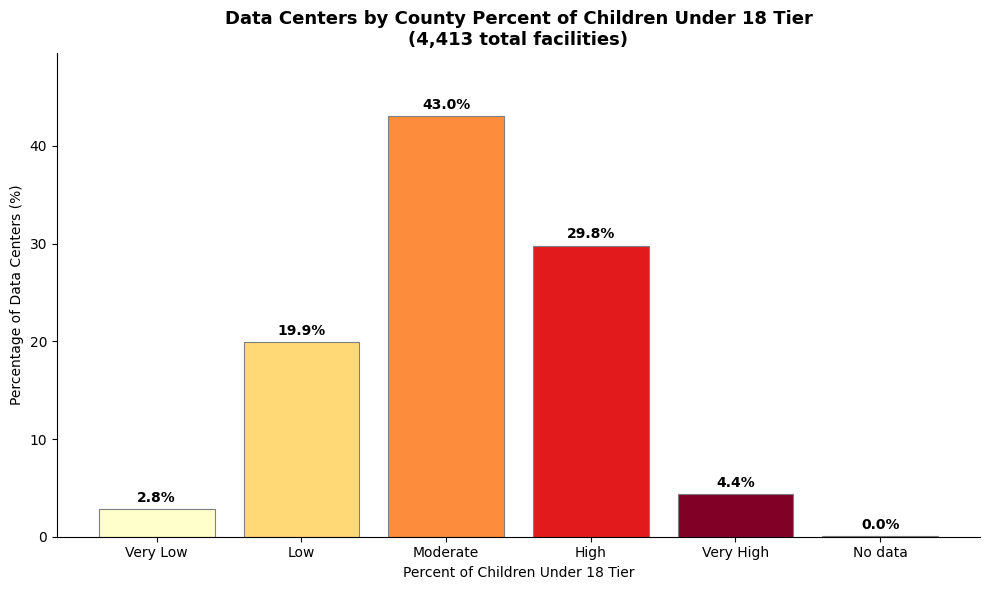

In [1]:
# Run once
# !pip install geopandas pandas numpy matplotlib openpyxl

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Load & clean county-level percent-children data ----
file = "/content/ACSDP5Y2023.DP05-2026-06-18T144252.xlsx"

acs_data = pd.read_excel(
    file,
    sheet_name="Data",
    header=None
)

# Under 18 years
under18_row = acs_data[acs_data[0] == "Under 18 years"].index[0]

# Every county starts at column 5, then repeats every 4 columns:
# Estimate, Margin of Error, Percent, Percent Margin of Error
county_columns = list(range(5, acs_data.shape[1], 4))

children_data = []

for col in county_columns:
    county_name = acs_data.iloc[0, col]
    percent_under18 = acs_data.iloc[under18_row, col + 2]

    children_data.append({
        "county_state": county_name,
        "percent_children": percent_under18
    })

children_df = pd.DataFrame(children_data)

# Remove missing county names
children_df = children_df[children_df["county_state"].notna()].copy()

# Clean percent column
children_df["percent_children"] = (
    children_df["percent_children"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

children_df["percent_children"] = pd.to_numeric(
    children_df["percent_children"],
    errors="coerce"
)

# Split county and state from names like "Autauga County, Alabama"
children_df[["county", "state"]] = children_df["county_state"].str.rsplit(
    ", ",
    n=1,
    expand=True
)

# ---- Load data center / facility locations ----
facilities_file = "/content/facilities_final_complete.xlsx"

facilities = pd.read_excel(
    facilities_file,
    sheet_name="facilities_final_complete"
)

# Clean fips the same way as the county data so they can be matched
facilities["fips"] = facilities["fips"].astype(int).astype(str).str.zfill(5)

total_facility_count = len(facilities)

# ---- Load county shapefile, just to get the name -> GEOID crosswalk ----
# children_df only has county/state names, not FIPS, so this map's own
# NAMELSAD + STATE_NAME merge is reused here to bring in a GEOID that
# facilities can actually be matched against.
county_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
counties = gpd.read_file(county_url)

crosswalk = counties[["GEOID", "NAMELSAD", "STATE_NAME"]].merge(
    children_df,
    left_on=["NAMELSAD", "STATE_NAME"],
    right_on=["county", "state"],
    how="left"
)

# ---- Build the same 5-tier percent-children scale used on the map ----
# (2nd-98th percentile range split into 5 equal-width bins)
children_values = crosswalk["percent_children"].dropna()
vmin = children_values.quantile(0.02)
vmax = children_values.quantile(0.98)
bins = np.linspace(vmin, vmax, 6)

crosswalk["children_bin"] = pd.cut(
    crosswalk["percent_children"],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Clamp out-of-range values into the first/last tier
crosswalk.loc[crosswalk["percent_children"] < vmin, "children_bin"] = 0
crosswalk.loc[crosswalk["percent_children"] > vmax, "children_bin"] = 4

# ---- Match each facility to its county's percent-children tier ----
facility_tiers = facilities.merge(
    crosswalk[["GEOID", "children_bin"]],
    left_on="fips",
    right_on="GEOID",
    how="left"
)

# Percent-children severity tier names & colors, low -> high (same as map legend)
tier_names = ["Very Low", "Low", "Moderate", "High", "Very High"]
tier_colors = ["#FFFFCC", "#FED976", "#FD8D3C", "#E31A1C", "#800026"]
missing_color = "#D9D9D9"

# Count data centers in each tier
counts = [(facility_tiers["children_bin"] == i).sum() for i in range(5)]
no_data_count = facility_tiers["children_bin"].isna().sum()

labels = tier_names + ["No data"]
values = counts + [no_data_count]
colors = tier_colors + [missing_color]

# Convert counts to a percentage of all facilities
percentages = [v / total_facility_count * 100 for v in values]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels,
    percentages,
    color=colors,
    edgecolor="#7f7f7f",
    linewidth=0.8
)

# Percentage label above each bar
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(percentages) * 0.01,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    f"Data Centers by County Percent of Children Under 18 Tier\n({total_facility_count:,} total facilities)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Percent of Children Under 18 Tier")
ax.set_ylabel("Percentage of Data Centers (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(percentages) * 1.15)

plt.tight_layout()
plt.show()